# Image generation using a conditional GAN

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx207_GAN_image_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

In this tutorial, you will train a conditional GAN to translate segmentation masks into realistic electron microscopy images. The dataset contains raw ssTEM images paired with segmentation maps that identify structures in the tissue.

You will prepare the dataset, build the generator and discriminator, train the GAN to generate images, and finally evaluate the model by comparing generated images with the ground truth.

## 1. Preparing the dataset

You start by downloading the dataset...

In [2]:
import os

if not os.path.exists("tissue_images_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/tissue_images_dataset")

raw_path = os.path.join("tissue_images_dataset", "stack1", "raw")
seg_path = os.path.join("tissue_images_dataset", "stack1", "labels")

... and splitting them into training, validation, and test sets.



In [3]:
import deeptrack as dt

raw_paths = dt.sources.ImageFolder(root=raw_path)
seg_paths = dt.sources.ImageFolder(root=seg_path)
paths = dt.sources.Source(raw=raw_paths, label=seg_paths)
train_paths, val_paths, test_paths = \
    dt.sources.random_split(paths, [0.8, 0.1, 0.1])

train_srcs = train_paths.product(flip_ud=[True, False], flip_lr=[True, False])
val_srcs = val_paths.constants(flip_ud=False, flip_lr=False)
test_srcs = test_paths.constants(flip_ud=False, flip_lr=False)

sources = dt.sources.Join(train_srcs, val_srcs, test_srcs)

C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\deeptrack\__init__.py:14: UserWarning: TensorFlow is detected in your environment. DeepTrack2 version 2.0++ no longer supports TensorFlow. If you need TensorFlow support, please install the legacy version 1.7 of DeepTrack2:

    pip install deeptrack==1.7

For more details, refer to the DeepTrack documentation.
  warnings.warn(
C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [4]:
print(f"Raw images: {len(raw_paths)}")
print(f"Segmentation labels: {len(seg_paths)}")

Raw images: 20
Segmentation labels: 20


Next, a function to extract the membrane, background, and mitochondria channels from the segmentation masks is defined.

In [5]:
import numpy as np

def select_labels(class_labels):
    """Create a function to filter and remap labels in a segmentation map."""
    def inner(segmentation):
        seg = segmentation.copy()
        mask = seg * np.isin(seg, class_labels).astype(np.uint8)
        new_seg = (np.select([mask == c for c in class_labels],
                             np.arange(len(class_labels)) + 1)
                   .astype(np.uint8).squeeze())
        one_hot_encoded_seg = np.eye(len(class_labels) + 1)[new_seg]
        return one_hot_encoded_seg        
    return inner

### 1.1 Preprocessing the data

The microscopy images are normalized to the range [-1, 1]. Simple augmentations, such as horizontal and vertical flips, are applied to increase the variety of examples and improve generalization.

A small amount of Gaussian noise is added to the segmentation masks. This slightly perturbs the masks, preventing the generator from overfitting to perfectly clean boundaries and making it more robust to imperfect inputs.

To make the training more efficient, the images are cropped into patches of 128 × 128 pixels. If you choose a larger crop size, your GAN may generalize better across tissue, but training will be slower and may need additional epochs.

In [6]:
import torch
im_pip = dt.LoadImage(sources.raw.path) >> dt.NormalizeMinMax(-1, 1)

noise = dt.Gaussian(mu=0, sigma=lambda: np.random.rand()*0.4)

seg_pip = (dt.LoadImage(sources.label.path)
           >> dt.Lambda(select_labels, class_labels=[255, 191]) >> noise)
 
pip = ((seg_pip & im_pip) >> dt.FlipLR(sources.flip_lr)
       >> dt.FlipUD(sources.flip_ud) >> dt.Crop(crop=(128, 128, 3))
       >> dt.MoveAxis(2, 0) >> dt.pytorch.ToTensor(dtype=torch.float))

Next, the datasets for training, validation, and testing are defined. The parameter `replace=0.15` means that about 15% of the dataset is refreshed each epoch, exposing the model to new examples and improving generalization.

In [7]:
train_dataset = dt.pytorch.Dataset(pip, train_srcs, replace=0.15)
val_dataset = dt.pytorch.Dataset(pip, val_srcs, replace=0.15)
test_dataset = dt.pytorch.Dataset(pip, test_srcs, replace=0.15)

### 1.2 Visualizing the data

Before training, it is useful to inspect the dataset. Plotting a few examples lets you confirm that the raw images and segmentation masks are aligned and that preprocessing worked as expected

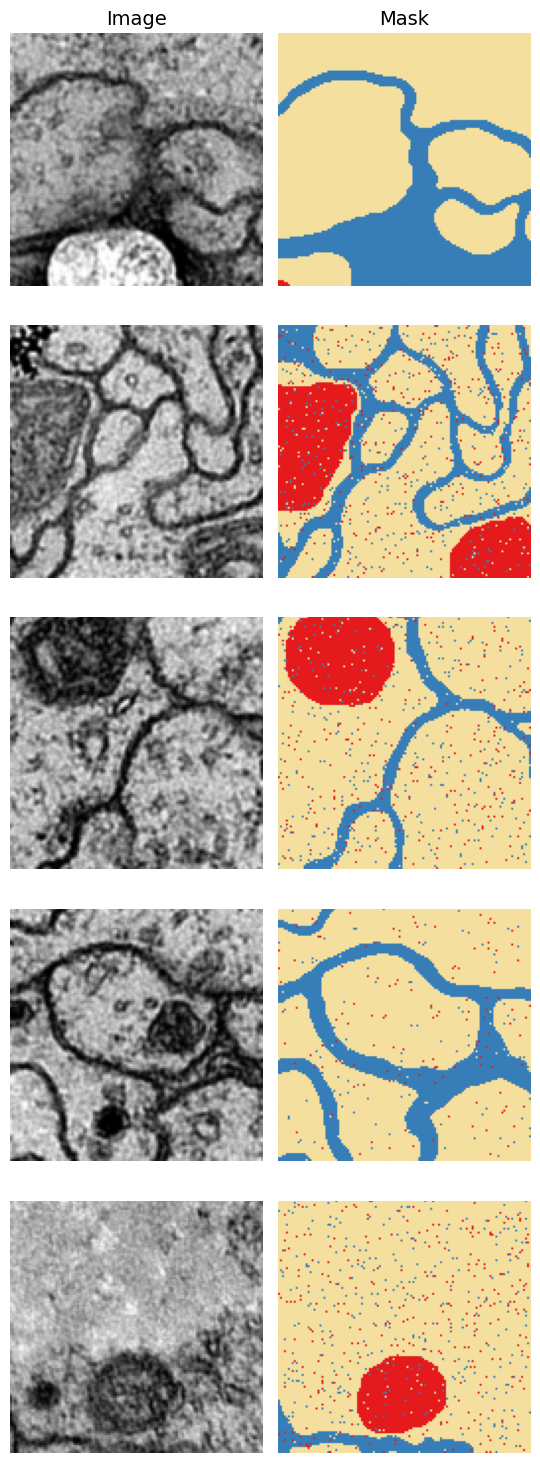

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#377eb8", "#f4df9e", "#e41a1c"])

number_of_images = 5

fig, axs = plt.subplots(
    number_of_images, 2, figsize=(5.5, 3 * number_of_images)
)

for i in range(number_of_images):
    segmentation, image = train_dataset[i]

    axs[i, 0].imshow(image.permute(1, 2, 0), cmap="gray")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(
        segmentation.argmax(dim=0).cpu().numpy(),
        cmap=cmap,
        vmin=0,
        vmax=segmentation.shape[0],
    )
    axs[i, 1].axis("off")

axs[0, 0].set_title("Image", fontsize=14)
axs[0, 1].set_title("Mask", fontsize=14)

plt.tight_layout()
plt.show()

## 2. Defining the model

The conditional GAN is composed of two submodels: a generator and a discriminator.

First, you determine which device will be used for computations.

In [9]:
def get_device():
    """Select device where to perform the computations."""
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Selected device: {device}")

Selected device: cuda:0


### 2.1 Building the generator

The generator is a U-Net model. It takes a segmentation mask as input and is trained to produce a microscopy image as output.
 
The final layer uses a Tanh activation function to keep the output values in the range [-1, 1].

In [10]:
import deeplay as dl
from torch.nn import InstanceNorm2d, LeakyReLU, Tanh

gen = dl.UNet2d(
    in_channels=3, channels=[32, 64, 128, 256, 512], out_channels=1,
)
gen["encoder", ..., "activation"].configure(LeakyReLU, negative_slope=0.2)
gen["decoder", ..., "activation#:-1"].configure(LeakyReLU, negative_slope=0.2)
gen["decoder", ..., "activation#-1"].configure(Tanh)
gen["decoder", "blocks", :-1].all.normalized(InstanceNorm2d)
gen[..., "blocks"].configure(order=["layer", "normalization", "activation"])
gen.build().to(device);

print(gen)

C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\kornia\feature\lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


UNet2d(
  (encoder): ConvolutionalEncoder2d(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
      (1): Conv2dBlock(
        (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
      (2): Conv2dBlock(
        (layer): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
      (3): Conv2dBlock(
        (layer): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
      (4): Conv2dBlock(
        (layer): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
    )
    (postprocess): Identity()
  )
  (bottleneck): ConvolutionalNeuralNetwork(
    (bl

### 2.2 Building the discriminator
The discriminator is a convolutional neural network that receives both the mask and an image (real or generated). Its task is to decide whether the image is real or fake.

The last layer uses a Sigmoid activation so that the output can be interpreted as a probability.

In [11]:
from torch.nn import Sigmoid

disc = dl.ConvolutionalNeuralNetwork(
    in_channels=(3+1), hidden_channels=[8, 16, 32, 64], out_channels=1,
)
disc["blocks", ..., "layer"].configure(kernel_size=4, stride=2, padding=1)
disc["blocks", 1:-1].all.normalized(InstanceNorm2d)
disc["blocks", ..., "activation#-1"].configure(Sigmoid)
disc["blocks"].configure(order=["layer", "normalization", "activation"])
disc.build().to(device);

print(disc)

ConvolutionalNeuralNetwork(
  (blocks): LayerList(
    (0): Conv2dBlock(
      (layer): Conv2d(4, 8, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (activation): ReLU()
    )
    (1): Conv2dBlock(
      (layer): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (normalization): InstanceNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (activation): ReLU()
    )
    (2): Conv2dBlock(
      (layer): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (normalization): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (activation): ReLU()
    )
    (3): Conv2dBlock(
      (layer): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (normalization): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (activation): ReLU()
    )
    (4): Conv2dBlock(
      (layer): Conv2d(64, 1, kernel_size=(4, 4), stride=(2, 2)

## 3. Training the GAN
### 3.1 Setting the loss functions and defining the optimizers

The GAN has two objectives. The discriminator learns to distinguish real images from generated ones, while the generator tries to both fool the discriminator and produce images that closely match the real targets.  

The generator loss has two parts. The adversarial loss comes from the discriminator’s predictions and indirectly encourages the generator to produce realistic images. The reconstruction losses (MAE and MSE) ensure the outputs match the ground truth. MAE emphasizes fine details, while MSE penalizes larger errors and stabilizes training.

In [12]:
loss_disc = torch.nn.MSELoss()

loss_recon_mae = torch.nn.L1Loss()
# loss_recon_mse = torch.nn.MSELoss()

Next, the optimizers for the generator and discriminator are defined.

In [13]:
optim_gen = torch.optim.Adam(gen.parameters(), lr=.0002, betas=(.5, .999))
optim_disc = torch.optim.Adam(disc.parameters(), lr=.00005, betas=(.5, .999))

### 3.2 Defining the dataloaders
Dataloaders are created for the training, validation, and test sets.

In [14]:
train_loader = dl.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = dl.DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = dl.DataLoader(test_dataset, batch_size=2, shuffle=False)

### 3.3 Defining the training process
Defining the training of the discriminator...

In [15]:
def train_disc(inputs, targets, optim_disc, loss_disc):
    """Train the discriminator."""
    optim_disc.zero_grad()

    # Compute real loss.
    disc_outputs_real = disc(torch.cat([inputs, targets], dim=1))
    labels_real = torch.ones_like(disc_outputs_real)
    disc_loss_real = loss_disc(disc_outputs_real, labels_real)

    # Compute fake loss.
    gen_outputs = gen(inputs)
    disc_outputs_fake = disc(torch.cat([inputs, gen_outputs], dim=1))
    labels_fake = torch.zeros_like(disc_outputs_fake)
    disc_loss_fake = loss_disc(disc_outputs_fake, labels_fake)

    disc_loss = (disc_loss_real + disc_loss_fake) / 2
    disc_loss.backward()
    optim_disc.step()

    return disc_loss

.. and of the generator.

In [16]:
def train_gen(inputs, targets, optim_gen, loss_disc, loss_recon_mae,
        recon_coef_mae=0.8):#, recon_coef_mse=0):
    """Train the generator."""
    optim_gen.zero_grad()

    gen_outputs = gen(inputs)
    disc_outputs = disc(torch.cat([inputs, gen_outputs], dim=1))

    labels = torch.ones_like(disc_outputs)
    adv_loss = loss_disc(disc_outputs, labels)
    recon_loss_mae = loss_recon_mae(gen_outputs, targets)
    # recon_loss_mse = loss_recon_mse(gen_outputs, targets)

    gen_loss = (
        adv_loss
        + recon_coef_mae * recon_loss_mae
        # + recon_coef_mse * recon_loss_mse
    )
    gen_loss.backward()
    optim_gen.step()

    return gen_loss, adv_loss, recon_loss_mae#, recon_loss_mse

### 3.4 Evaluating the model

During training, or after it is complete, you can evaluate the model on validation or test data. The mask, the generated image, and the ground truth image are shown side by side.  

This visualization allows you to see whether the GAN has learned to produce realistic microscopy images that match the segmentation masks.


In [17]:
def evaluate_model(input, target):
    """Evaluate model on validation or test data."""
    gen.eval()
    with torch.no_grad():
        prediction = gen(input.to(device))
    gen.train()

    fig, axs = plt.subplots(2, 3, figsize=(10, 8))

    axs[0, 0].imshow(
        input[0].argmax(dim=0).cpu().numpy(),
        cmap=cmap,
        vmin=0,
        vmax=input.shape[1],
    )
    axs[0, 0].axis("off")

    axs[0, 1].imshow(prediction[0].permute(1, 2, 0).cpu(), cmap="gray")
    axs[0, 1].axis("off")

    axs[0, 2].imshow(target[0].permute(1, 2, 0).cpu(), cmap="gray")
    axs[0, 2].axis("off")

    axs[1, 0].imshow(
        input[1].argmax(dim=0).cpu().numpy(),
        cmap=cmap,
        vmin=0,
        vmax=input.shape[1],
    )
    axs[1, 0].axis("off")

    axs[1, 1].imshow(prediction[1].permute(1, 2, 0).cpu(), cmap="gray")
    axs[1, 1].axis("off")

    axs[1, 2].imshow(target[1].permute(1, 2, 0).cpu(), cmap="gray")
    axs[1, 2].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

### 3.5 Training loop

The training loop iterates over 250 epochs. For each batch, the discriminator is trained first, followed by the generator.  

After each epoch, average losses are computed and printed, giving you an overview of training progress. Periodically, the model is evaluated on the validation set to visually inspect its performance.


Epoch 1/250
----------
Batch 1/16 : Total Generator Loss: 0.4461, Discriminator Loss: 0.2593
Batch 8/16 : Total Generator Loss: 0.4411, Discriminator Loss: 0.2549
Batch 15/16 : Total Generator Loss: 0.4489, Discriminator Loss: 0.2541
----------
Epoch 1/250 : Discriminator Loss: 0.2544, Total Generator Loss: 0.4560, Reconstruction Loss MAE: 0.2615, Time taken: 0:00:08.733214


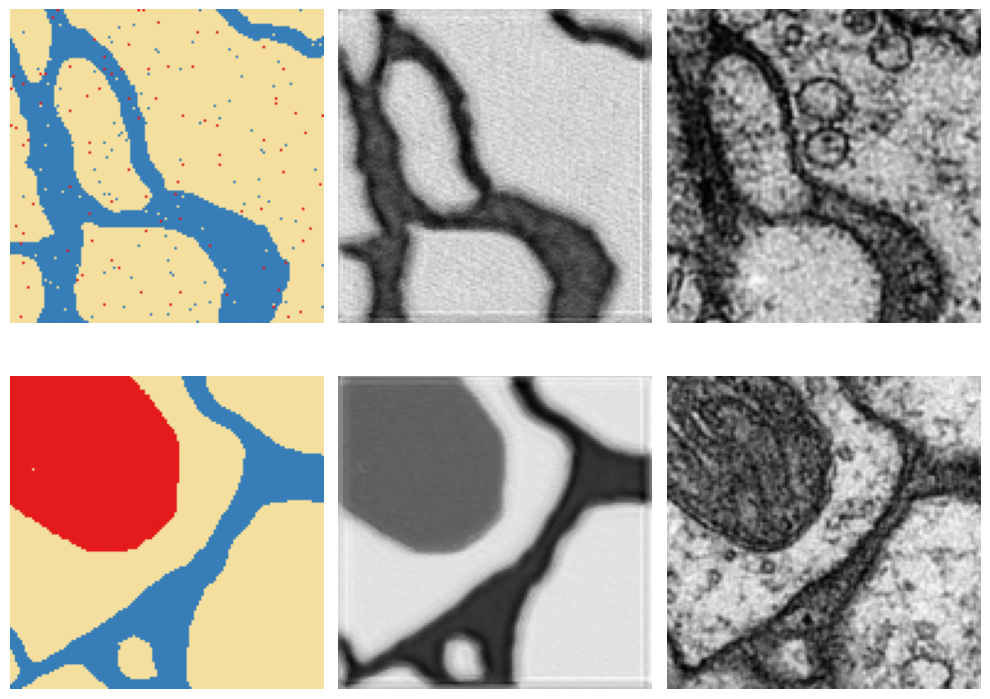


Epoch 2/250
----------
Batch 1/16 : Total Generator Loss: 0.4828, Discriminator Loss: 0.2506
Batch 8/16 : Total Generator Loss: 0.4469, Discriminator Loss: 0.2542
Batch 15/16 : Total Generator Loss: 0.4845, Discriminator Loss: 0.2495
----------
Epoch 2/250 : Discriminator Loss: 0.2534, Total Generator Loss: 0.4595, Reconstruction Loss MAE: 0.2571, Time taken: 0:00:09.551567

Epoch 3/250
----------
Batch 1/16 : Total Generator Loss: 0.4608, Discriminator Loss: 0.2544
Batch 8/16 : Total Generator Loss: 0.4441, Discriminator Loss: 0.2525
Batch 15/16 : Total Generator Loss: 0.4451, Discriminator Loss: 0.2485
----------
Epoch 3/250 : Discriminator Loss: 0.2517, Total Generator Loss: 0.4628, Reconstruction Loss MAE: 0.2570, Time taken: 0:00:09.723341

Epoch 4/250
----------
Batch 1/16 : Total Generator Loss: 0.4605, Discriminator Loss: 0.2564
Batch 8/16 : Total Generator Loss: 0.4526, Discriminator Loss: 0.2525
Batch 15/16 : Total Generator Loss: 0.4874, Discriminator Loss: 0.2505
---------

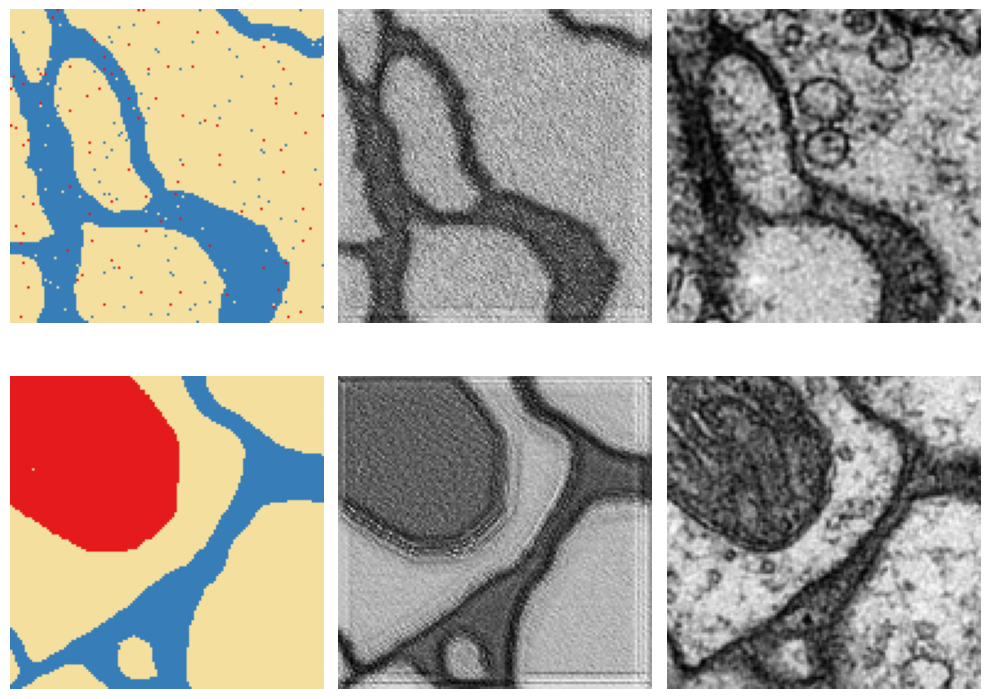


Epoch 27/250
----------
Batch 1/16 : Total Generator Loss: 0.4528, Discriminator Loss: 0.2688
Batch 8/16 : Total Generator Loss: 0.4604, Discriminator Loss: 0.2632
Batch 15/16 : Total Generator Loss: 0.4574, Discriminator Loss: 0.2630
----------
Epoch 27/250 : Discriminator Loss: 0.2618, Total Generator Loss: 0.4617, Reconstruction Loss MAE: 0.2733, Time taken: 0:00:09.329140

Epoch 28/250
----------
Batch 1/16 : Total Generator Loss: 0.4572, Discriminator Loss: 0.2639
Batch 8/16 : Total Generator Loss: 0.4639, Discriminator Loss: 0.2603
Batch 15/16 : Total Generator Loss: 0.4422, Discriminator Loss: 0.2664
----------
Epoch 28/250 : Discriminator Loss: 0.2618, Total Generator Loss: 0.4617, Reconstruction Loss MAE: 0.2747, Time taken: 0:00:09.202764

Epoch 29/250
----------
Batch 1/16 : Total Generator Loss: 0.4508, Discriminator Loss: 0.2696
Batch 8/16 : Total Generator Loss: 0.4653, Discriminator Loss: 0.2610
Batch 15/16 : Total Generator Loss: 0.4519, Discriminator Loss: 0.2648
----

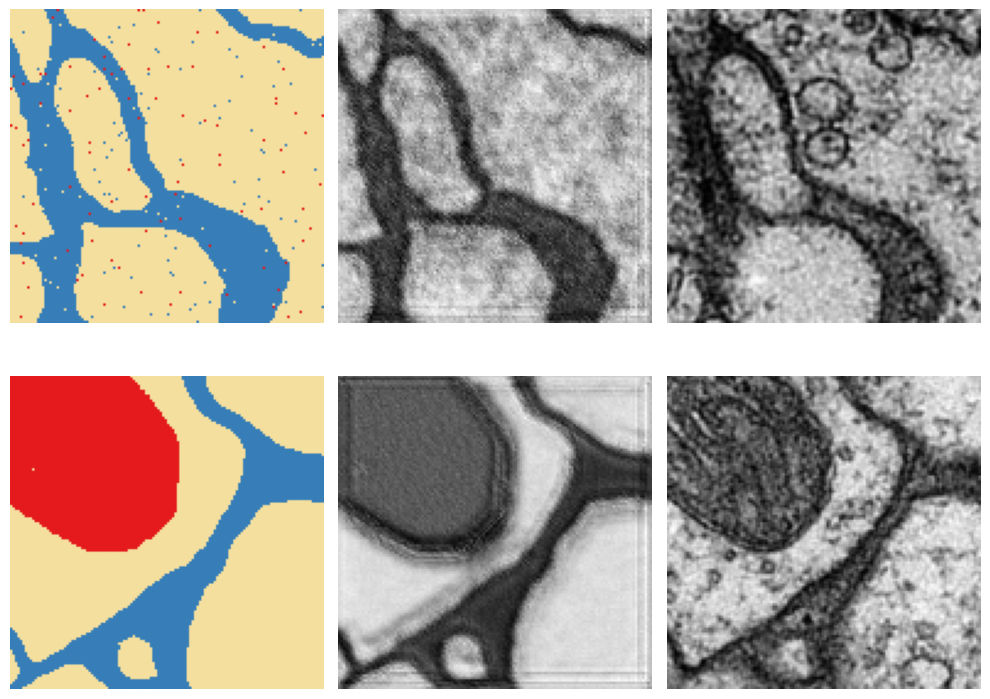


Epoch 52/250
----------
Batch 1/16 : Total Generator Loss: 0.4607, Discriminator Loss: 0.2466
Batch 8/16 : Total Generator Loss: 0.4417, Discriminator Loss: 0.2503
Batch 15/16 : Total Generator Loss: 0.4622, Discriminator Loss: 0.2458
----------
Epoch 52/250 : Discriminator Loss: 0.2492, Total Generator Loss: 0.4587, Reconstruction Loss MAE: 0.2555, Time taken: 0:00:07.853481

Epoch 53/250
----------
Batch 1/16 : Total Generator Loss: 0.4630, Discriminator Loss: 0.2454
Batch 8/16 : Total Generator Loss: 0.4912, Discriminator Loss: 0.2450
Batch 15/16 : Total Generator Loss: 0.4624, Discriminator Loss: 0.2431
----------
Epoch 53/250 : Discriminator Loss: 0.2497, Total Generator Loss: 0.4594, Reconstruction Loss MAE: 0.2567, Time taken: 0:00:08.145607

Epoch 54/250
----------
Batch 1/16 : Total Generator Loss: 0.4638, Discriminator Loss: 0.2497
Batch 8/16 : Total Generator Loss: 0.4546, Discriminator Loss: 0.2538
Batch 15/16 : Total Generator Loss: 0.4828, Discriminator Loss: 0.2453
----

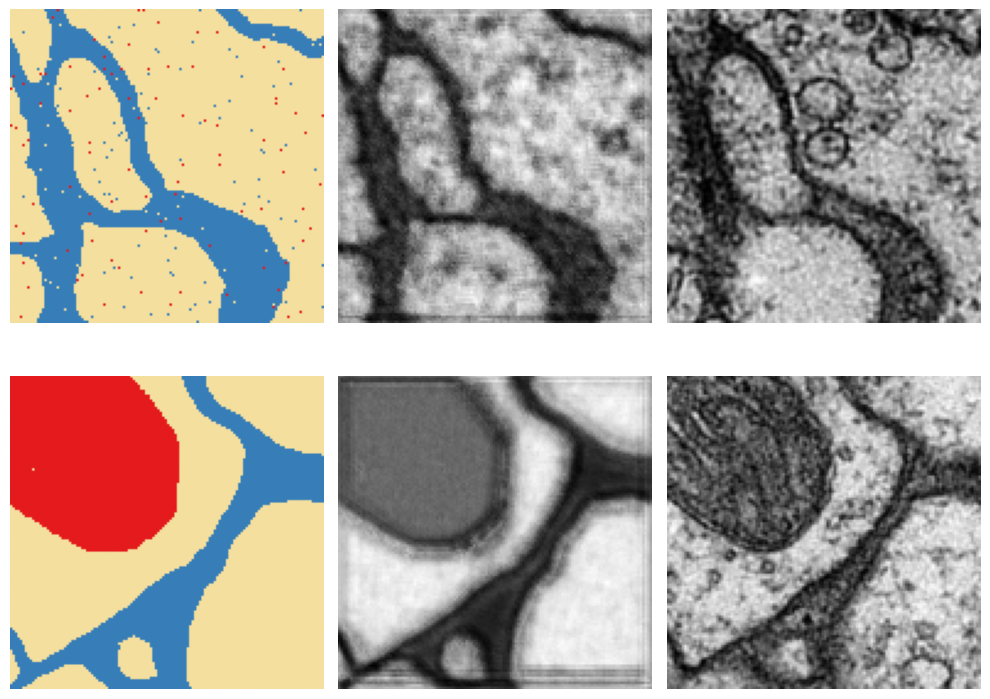


Epoch 77/250
----------
Batch 1/16 : Total Generator Loss: 0.4313, Discriminator Loss: 0.2576
Batch 8/16 : Total Generator Loss: 0.4397, Discriminator Loss: 0.2541
Batch 15/16 : Total Generator Loss: 0.4594, Discriminator Loss: 0.2478
----------
Epoch 77/250 : Discriminator Loss: 0.2506, Total Generator Loss: 0.4494, Reconstruction Loss MAE: 0.2466, Time taken: 0:00:08.512241

Epoch 78/250
----------
Batch 1/16 : Total Generator Loss: 0.4381, Discriminator Loss: 0.2549
Batch 8/16 : Total Generator Loss: 0.4528, Discriminator Loss: 0.2457
Batch 15/16 : Total Generator Loss: 0.4905, Discriminator Loss: 0.2434
----------
Epoch 78/250 : Discriminator Loss: 0.2500, Total Generator Loss: 0.4537, Reconstruction Loss MAE: 0.2505, Time taken: 0:00:08.176695

Epoch 79/250
----------
Batch 1/16 : Total Generator Loss: 0.4290, Discriminator Loss: 0.2579
Batch 8/16 : Total Generator Loss: 0.4360, Discriminator Loss: 0.2541
Batch 15/16 : Total Generator Loss: 0.4738, Discriminator Loss: 0.2437
----

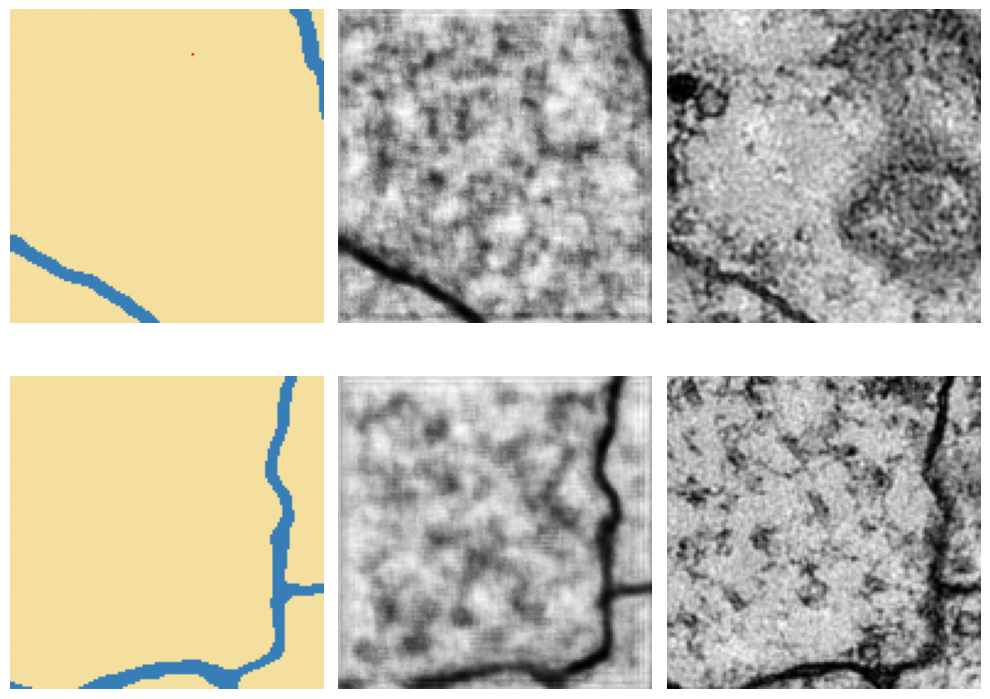


Epoch 102/250
----------
Batch 1/16 : Total Generator Loss: 0.4020, Discriminator Loss: 0.2610
Batch 8/16 : Total Generator Loss: 0.4715, Discriminator Loss: 0.2458
Batch 15/16 : Total Generator Loss: 0.4331, Discriminator Loss: 0.2537
----------
Epoch 102/250 : Discriminator Loss: 0.2515, Total Generator Loss: 0.4465, Reconstruction Loss MAE: 0.2439, Time taken: 0:00:09.879076

Epoch 103/250
----------
Batch 1/16 : Total Generator Loss: 0.4562, Discriminator Loss: 0.2471
Batch 8/16 : Total Generator Loss: 0.4162, Discriminator Loss: 0.2600
Batch 15/16 : Total Generator Loss: 0.4596, Discriminator Loss: 0.2504
----------
Epoch 103/250 : Discriminator Loss: 0.2522, Total Generator Loss: 0.4424, Reconstruction Loss MAE: 0.2388, Time taken: 0:00:09.858104

Epoch 104/250
----------
Batch 1/16 : Total Generator Loss: 0.4348, Discriminator Loss: 0.2513
Batch 8/16 : Total Generator Loss: 0.4554, Discriminator Loss: 0.2470
Batch 15/16 : Total Generator Loss: 0.4158, Discriminator Loss: 0.2523

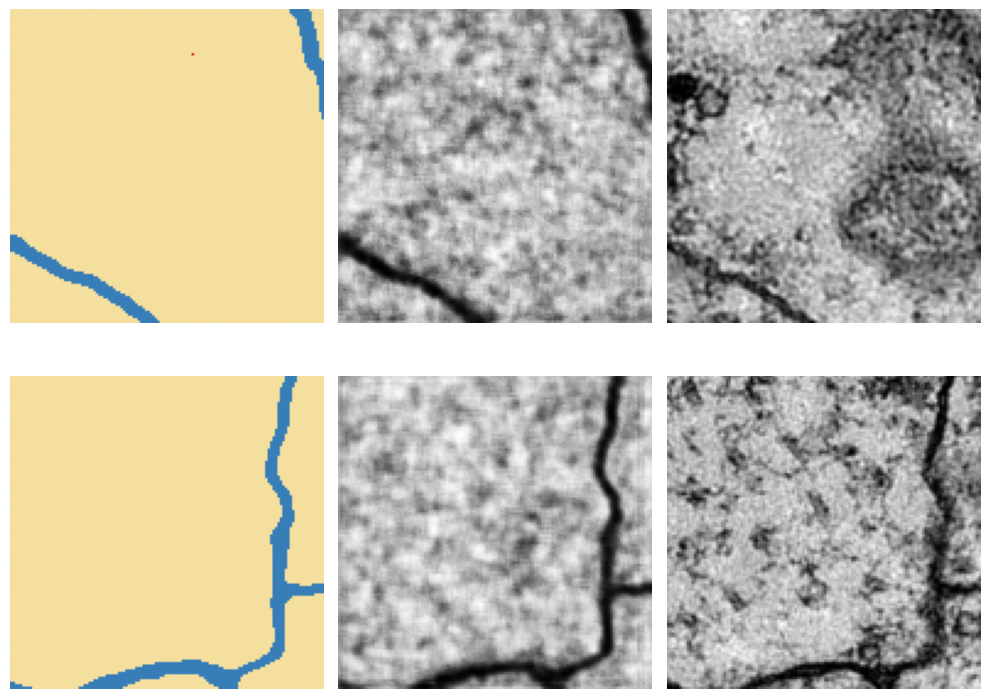


Epoch 127/250
----------
Batch 1/16 : Total Generator Loss: 0.4248, Discriminator Loss: 0.2472
Batch 8/16 : Total Generator Loss: 0.3986, Discriminator Loss: 0.2525
Batch 15/16 : Total Generator Loss: 0.4456, Discriminator Loss: 0.2462
----------
Epoch 127/250 : Discriminator Loss: 0.2518, Total Generator Loss: 0.4131, Reconstruction Loss MAE: 0.2031, Time taken: 0:00:08.941525

Epoch 128/250
----------
Batch 1/16 : Total Generator Loss: 0.3832, Discriminator Loss: 0.2537
Batch 8/16 : Total Generator Loss: 0.4336, Discriminator Loss: 0.2510
Batch 15/16 : Total Generator Loss: 0.4598, Discriminator Loss: 0.2474
----------
Epoch 128/250 : Discriminator Loss: 0.2522, Total Generator Loss: 0.4089, Reconstruction Loss MAE: 0.1994, Time taken: 0:00:08.727703

Epoch 129/250
----------
Batch 1/16 : Total Generator Loss: 0.4108, Discriminator Loss: 0.2505
Batch 8/16 : Total Generator Loss: 0.4663, Discriminator Loss: 0.2448
Batch 15/16 : Total Generator Loss: 0.4600, Discriminator Loss: 0.2463

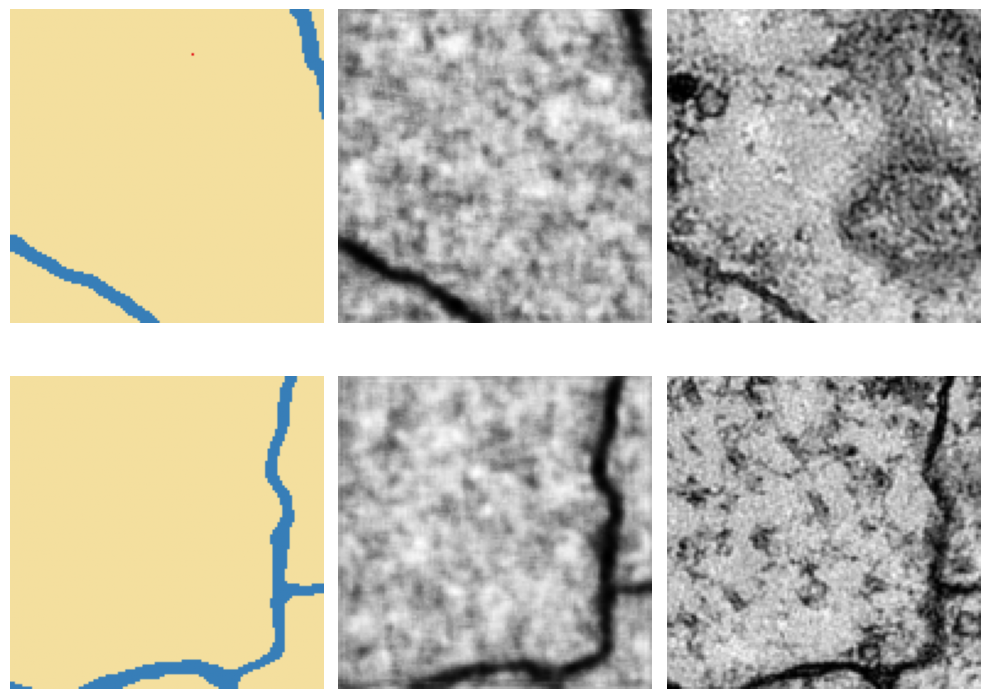


Epoch 152/250
----------
Batch 1/16 : Total Generator Loss: 0.4289, Discriminator Loss: 0.2521
Batch 8/16 : Total Generator Loss: 0.4360, Discriminator Loss: 0.2475
Batch 15/16 : Total Generator Loss: 0.4418, Discriminator Loss: 0.2480
----------
Epoch 152/250 : Discriminator Loss: 0.2506, Total Generator Loss: 0.4165, Reconstruction Loss MAE: 0.2089, Time taken: 0:00:10.038515

Epoch 153/250
----------
Batch 1/16 : Total Generator Loss: 0.4387, Discriminator Loss: 0.2506
Batch 8/16 : Total Generator Loss: 0.3927, Discriminator Loss: 0.2536
Batch 15/16 : Total Generator Loss: 0.3950, Discriminator Loss: 0.2510
----------
Epoch 153/250 : Discriminator Loss: 0.2518, Total Generator Loss: 0.4098, Reconstruction Loss MAE: 0.2014, Time taken: 0:00:09.201286

Epoch 154/250
----------
Batch 1/16 : Total Generator Loss: 0.4038, Discriminator Loss: 0.2553
Batch 8/16 : Total Generator Loss: 0.3853, Discriminator Loss: 0.2519
Batch 15/16 : Total Generator Loss: 0.3975, Discriminator Loss: 0.2506

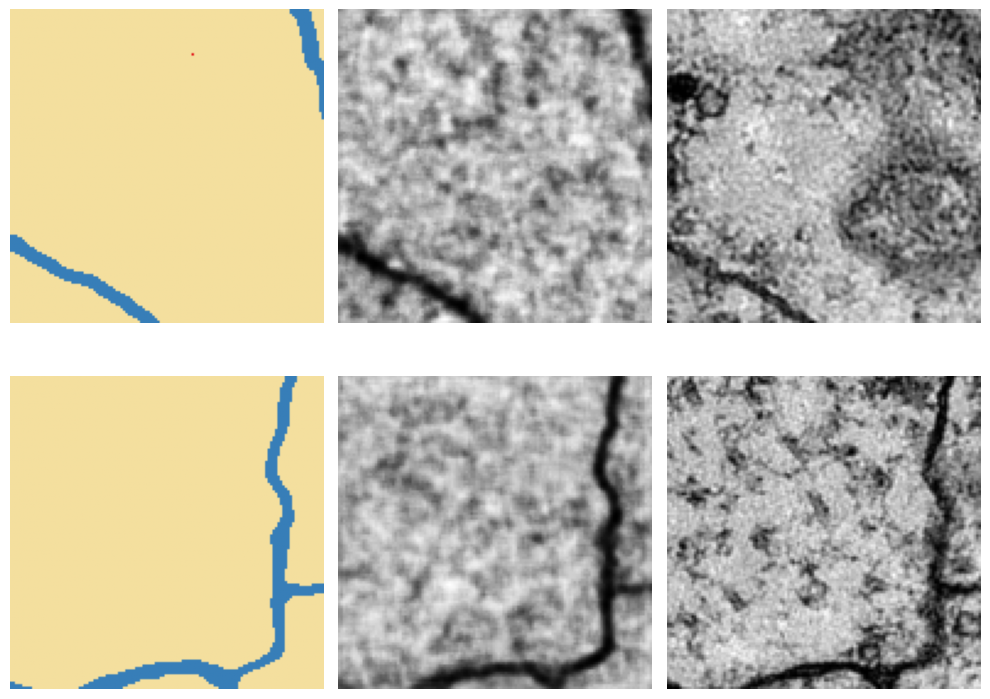


Epoch 177/250
----------
Batch 1/16 : Total Generator Loss: 0.4274, Discriminator Loss: 0.2455
Batch 8/16 : Total Generator Loss: 0.3728, Discriminator Loss: 0.2546
Batch 15/16 : Total Generator Loss: 0.4614, Discriminator Loss: 0.2449
----------
Epoch 177/250 : Discriminator Loss: 0.2500, Total Generator Loss: 0.4186, Reconstruction Loss MAE: 0.2081, Time taken: 0:00:16.814110

Epoch 178/250
----------
Batch 1/16 : Total Generator Loss: 0.4393, Discriminator Loss: 0.2476
Batch 8/16 : Total Generator Loss: 0.3860, Discriminator Loss: 0.2517
Batch 15/16 : Total Generator Loss: 0.3770, Discriminator Loss: 0.2527
----------
Epoch 178/250 : Discriminator Loss: 0.2503, Total Generator Loss: 0.4166, Reconstruction Loss MAE: 0.2071, Time taken: 0:00:15.044366

Epoch 179/250
----------
Batch 1/16 : Total Generator Loss: 0.4324, Discriminator Loss: 0.2426
Batch 8/16 : Total Generator Loss: 0.4068, Discriminator Loss: 0.2515
Batch 15/16 : Total Generator Loss: 0.4342, Discriminator Loss: 0.2482

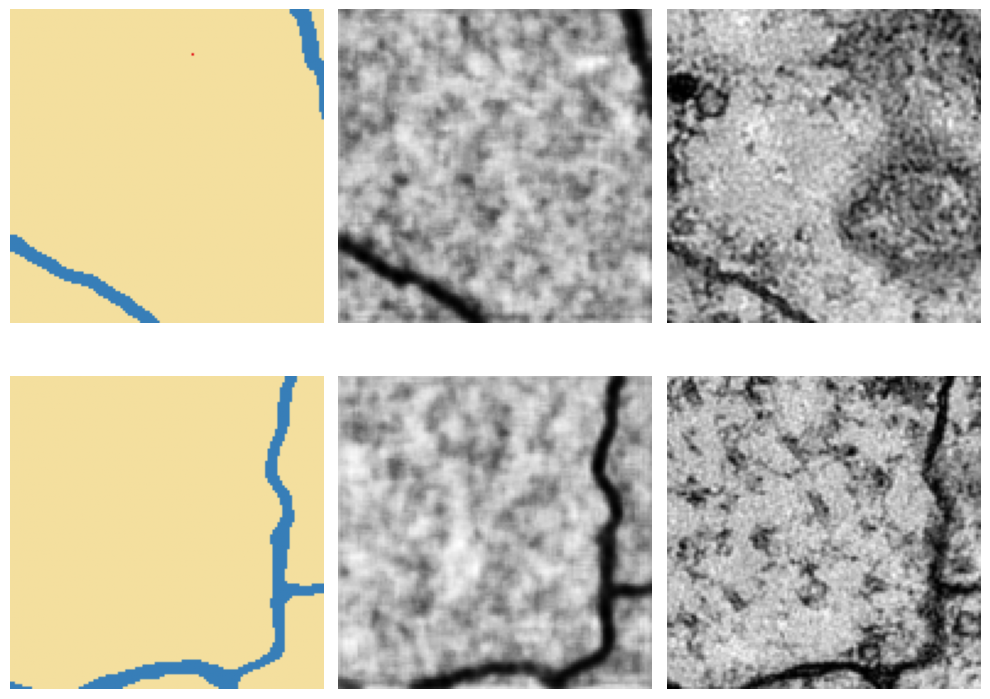


Epoch 202/250
----------
Batch 1/16 : Total Generator Loss: 0.4418, Discriminator Loss: 0.2489
Batch 8/16 : Total Generator Loss: 0.3988, Discriminator Loss: 0.2531
Batch 15/16 : Total Generator Loss: 0.4012, Discriminator Loss: 0.2526
----------
Epoch 202/250 : Discriminator Loss: 0.2512, Total Generator Loss: 0.4171, Reconstruction Loss MAE: 0.2097, Time taken: 0:00:09.317684

Epoch 203/250
----------
Batch 1/16 : Total Generator Loss: 0.4162, Discriminator Loss: 0.2516
Batch 8/16 : Total Generator Loss: 0.4051, Discriminator Loss: 0.2553
Batch 15/16 : Total Generator Loss: 0.4682, Discriminator Loss: 0.2428
----------
Epoch 203/250 : Discriminator Loss: 0.2505, Total Generator Loss: 0.4203, Reconstruction Loss MAE: 0.2110, Time taken: 0:00:07.916605

Epoch 204/250
----------
Batch 1/16 : Total Generator Loss: 0.5152, Discriminator Loss: 0.2550
Batch 8/16 : Total Generator Loss: 0.4665, Discriminator Loss: 0.2392
Batch 15/16 : Total Generator Loss: 0.4567, Discriminator Loss: 0.2454

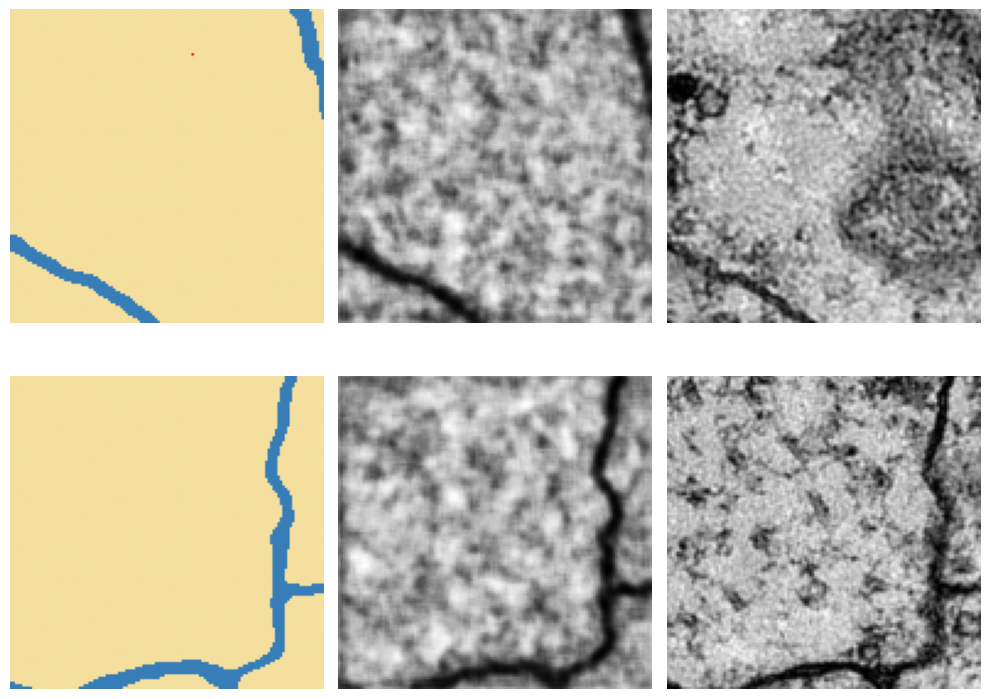


Epoch 227/250
----------
Batch 1/16 : Total Generator Loss: 0.4660, Discriminator Loss: 0.2463
Batch 8/16 : Total Generator Loss: 0.4268, Discriminator Loss: 0.2546
Batch 15/16 : Total Generator Loss: 0.4034, Discriminator Loss: 0.2528
----------
Epoch 227/250 : Discriminator Loss: 0.2497, Total Generator Loss: 0.4291, Reconstruction Loss MAE: 0.2210, Time taken: 0:00:09.483184

Epoch 228/250
----------
Batch 1/16 : Total Generator Loss: 0.3779, Discriminator Loss: 0.2557
Batch 8/16 : Total Generator Loss: 0.4052, Discriminator Loss: 0.2532
Batch 15/16 : Total Generator Loss: 0.4493, Discriminator Loss: 0.2448
----------
Epoch 228/250 : Discriminator Loss: 0.2496, Total Generator Loss: 0.4257, Reconstruction Loss MAE: 0.2187, Time taken: 0:00:09.541373

Epoch 229/250
----------
Batch 1/16 : Total Generator Loss: 0.4071, Discriminator Loss: 0.2517
Batch 8/16 : Total Generator Loss: 0.4220, Discriminator Loss: 0.2506
Batch 15/16 : Total Generator Loss: 0.4012, Discriminator Loss: 0.2499

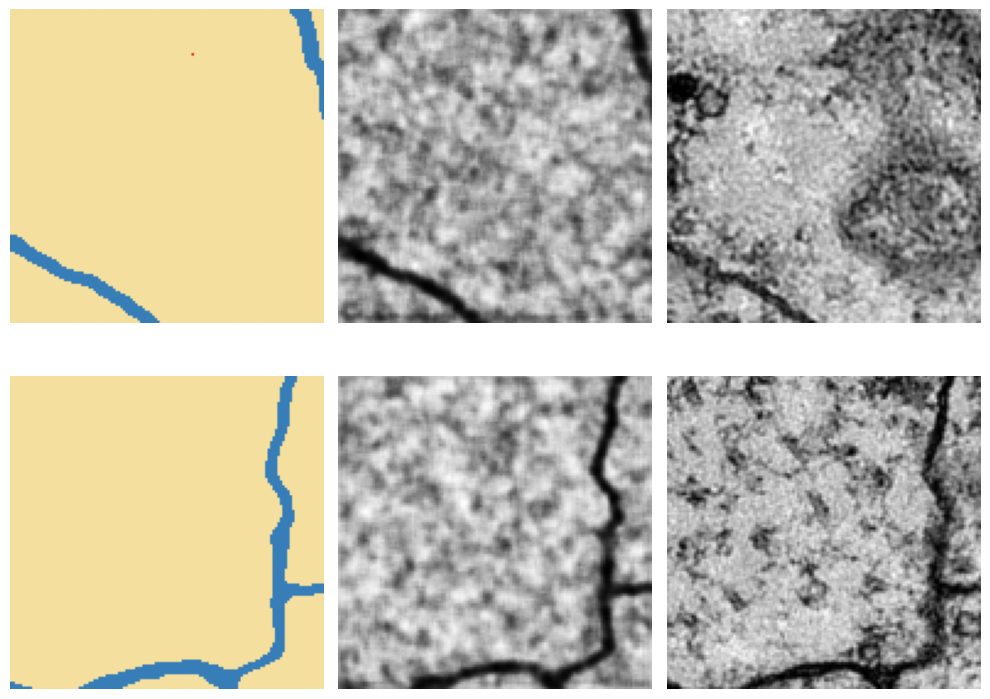

In [19]:
import time
from datetime import timedelta

epochs = 250

disc_losses, gen_losses, recon_losses_mae, recon_losses_mse = [], [], [], []
for epoch in range (epochs):
    start_time = time.time()
    print("\n" + f"Epoch {epoch + 1}/{epochs}" + "\n" + "-" * 10)

    disc_loss_epoch, gen_loss_epoch = [], []
    recon_loss_mae_epoch = [] #, recon_loss_mse_epoch = [], []
    for i, (inputs, targets) in enumerate(train_loader, 0):
        inputs, targets = inputs.to(device), targets.to(device)

        # 1. Train the discriminator.
        disc_loss = train_disc(inputs, targets, optim_disc, loss_disc)

        # 2. Train the generator.
        gen_loss, adv_loss, recon_loss_mae = train_gen(
            inputs, targets, optim_gen, loss_disc, loss_recon_mae #, loss_recon_mse
        )

        if i % 7 == 0:
            print(f"Batch {i + 1}/{len(train_loader)} : "
                  f"Total Generator Loss: {gen_loss.item():.4f}, "
                  f"Discriminator Loss: {disc_loss.item():.4f}")

        disc_loss_epoch.append(disc_loss.item())
        gen_loss_epoch.append(gen_loss.item())
        recon_loss_mae_epoch.append(recon_loss_mae.item())
        # recon_loss_mse_epoch.append(recon_loss_mse.item())
    
    end_time = time.time()

    disc_losses.append(np.mean(disc_loss_epoch))
    gen_losses.append(np.mean(gen_loss_epoch))
    recon_losses_mae.append(np.mean(recon_loss_mae_epoch))
    # recon_losses_mse.append(np.mean(recon_loss_mse_epoch))

    print(f"-" * 10 + "\n" + f"Epoch {epoch + 1}/{epochs} : "
          f"Discriminator Loss: {disc_losses[-1]:.4f}, "
          f"Total Generator Loss: {gen_losses[-1]:.4f}, "
          f"Reconstruction Loss MAE: {recon_losses_mae[-1]:.4f}, "
        #   f"Reconstruction Loss MSE: {recon_losses_mse[-1]:.4f}, "
          f"Time taken: {timedelta(seconds=end_time - start_time)}")

    if epoch % 25 == 0 or epoch + 1 == epochs:
        for i, (val_input, val_target) in enumerate(val_loader, 0):
            evaluate_model(val_input, val_target)

## 4. Evaluating the GAN on the test data

After training, you can evaluate the GAN on the test set to see how well it generalizes to unseen images. The results show the input mask, the generated image, and the corresponding ground truth image side by side.

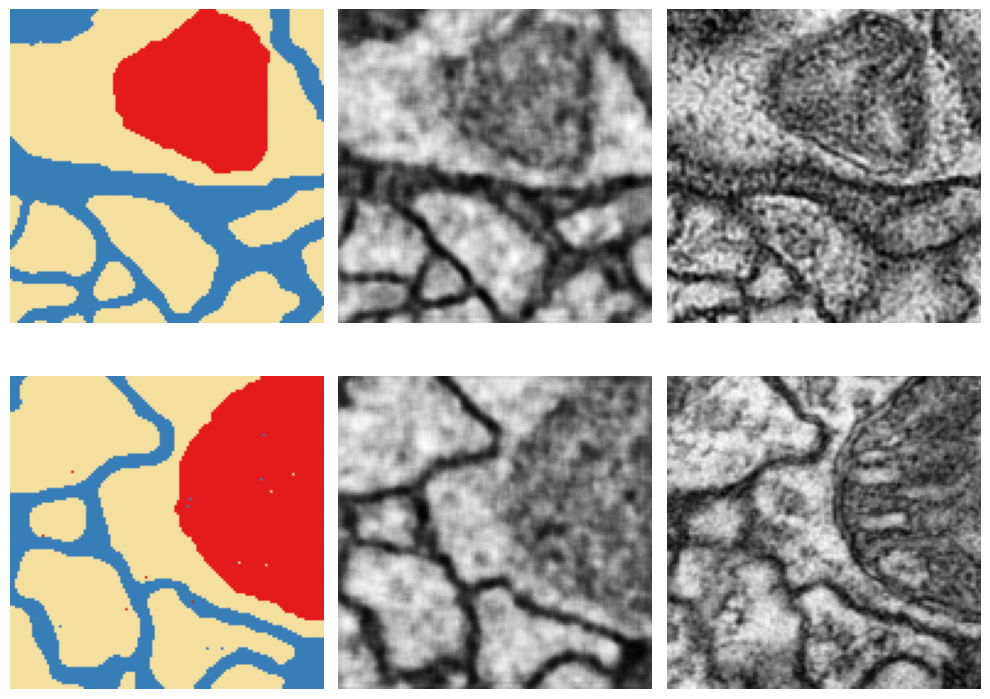

In [30]:
for i, (test_input, test_target) in enumerate(test_loader, 0):
    evaluate_model(test_input, test_target)